In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tabulate import tabulate
import warnings
import generate_synthetic_data as gsd
from collections import OrderedDict
import pandas as pd


## Read Data

In [2]:
# [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# data, labels = gsd.read_data_txt(IDs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
data, labels = gsd.read_data_txt(IDs = [10])


case    total    gammas    neutrons    ratio (g/n)    Amax total    Amax gammas    Amax neutrons
------  -------  --------  ----------  -------------  ------------  -------------  ---------------
case10  112695   58353     54342       1.1            1.6546        1.6546         0.6824
---     ---      ---       ---         ---            ---           ---            ---
Total   112695   58353     54342       1.1---         ---           ---


### Merge all cases together

In [3]:
data_merged, labels_merged, neutrons_merged, gammas_merged = gsd.merge_cases_together(data, labels)
data_merged.shape

(112695, 296)

In [4]:
# # sanity check
# for i in range(10):
#     plt.plot(data_merged[i]);

# Optimize


In [5]:
def ref_plot(n, g, Npulses = 1000, txt = 'selection'):
    fig, axs = plt.subplots(1, 2, figsize=(14, 4))
    for i in range(Npulses):
        axs[0].plot(n[i]);
        axs[0].set_title(f'{txt}: neutrons')
    for i in range(Npulses):
        axs[1].plot(g[i]);
        axs[1].set_title(f'{txt}: gammas')
    for i in range(0, 2):
            axs[i].set_xlabel("Pulse Sample", fontsize=12)
            axs[i].set_ylabel("Amplitude [V]", fontsize=12)
            axs[i].grid()
            axs[i].set_xlim(30, 100)
            # axs[i].set_ylim(0, 0.5)
    plt.tight_layout()
    plt.show()

Step                       N    eff_abs    eff_rel    N_neutron    eff_neutron    N_gamma    eff_gamma
--------------------  ------  ---------  ---------  -----------  -------------  ---------  -----------
Input                 112695     1.0000     1.0000        54342         1.0000      58353       1.0000
Peak position cut     110658     0.9819     0.9819        52555         0.9671      58103       0.9957
Energy selection      107218     0.9514     0.9689        52452         0.9652      54766       0.9385
Amplitude cut          37678     0.3343     0.3514        11982         0.2205      25696       0.4404
Afterpulse rejection   32412     0.2876     0.8602         6718         0.1236      25694       0.4403


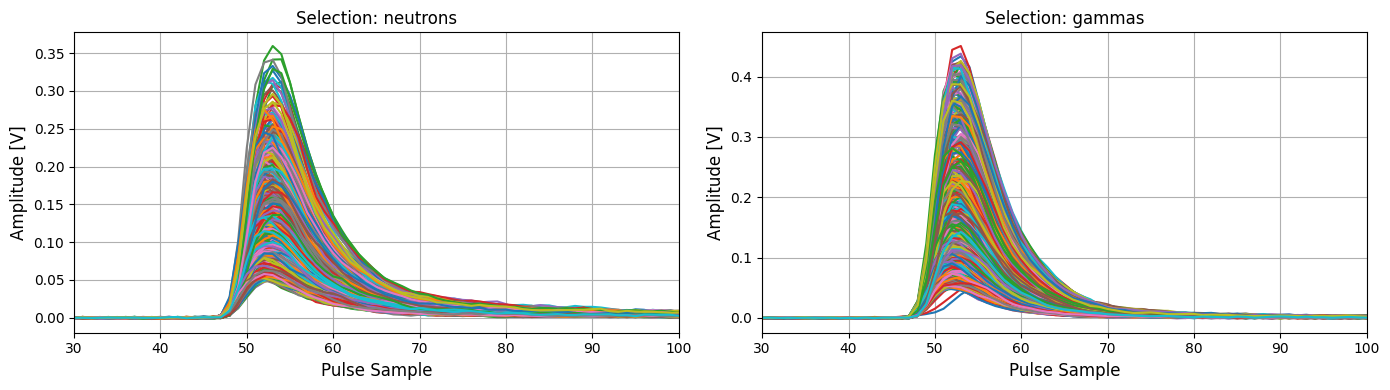

bin_edges [0.05 0.1  0.15 0.2  0.25 0.3  0.35]
bin_centers [0.075 0.125 0.175 0.225 0.275 0.325]

neutrons
 sample shape (6718, 296)
 peak amplitude (min, max) -0.0018 0.3595
 average peak amplitude 0.005922586154180383
 counts per bin: [2871 1956  974  598  246   70]

gammas
 sample shape (25694, 296)
 peak amplitude (min, max) -0.0022 0.4556
 average peak amplitude 0.004952052403652967
 counts per bin: [10432  5294  3569  2204  1592  1179]


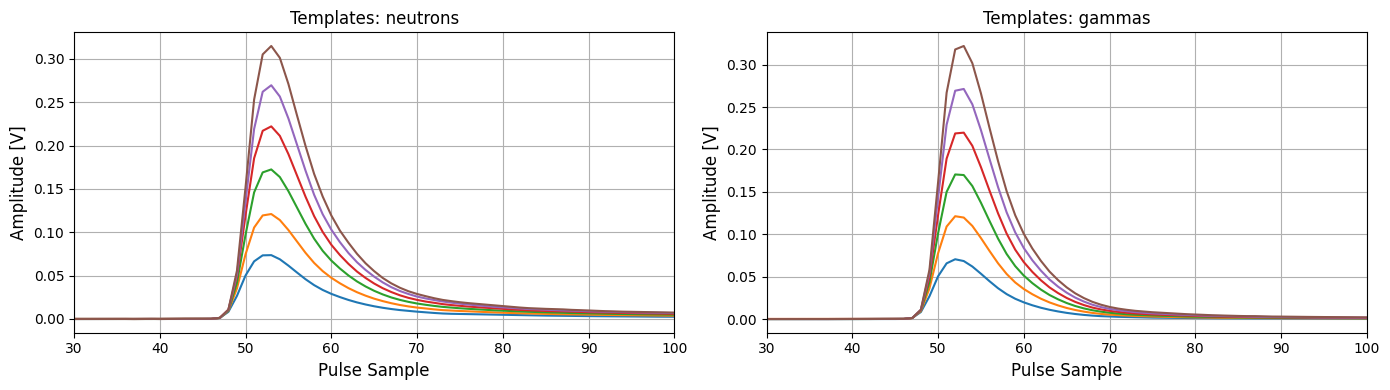

NEUTRONS
Clamped fraction: 0.08505714285714286
GAMMAS
Clamped fraction: 0.08468571428571428


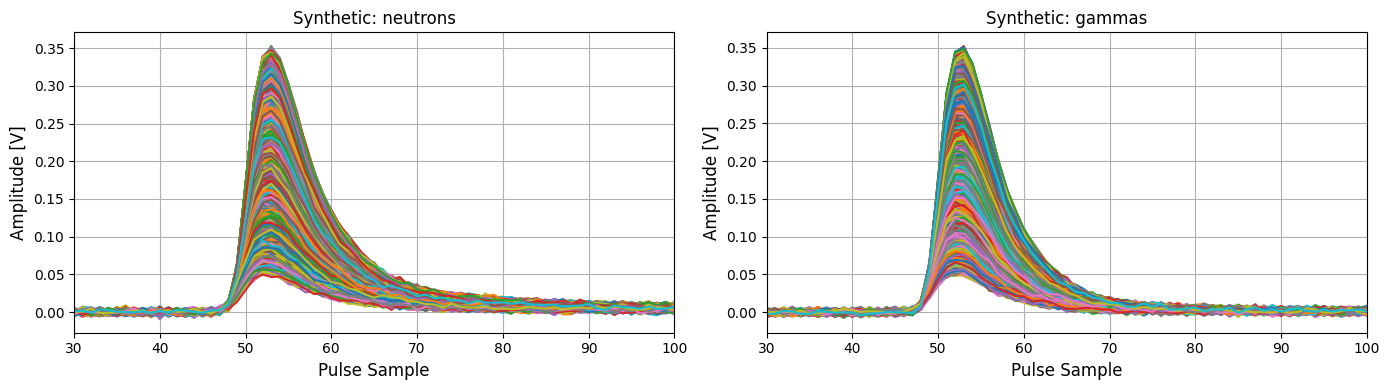

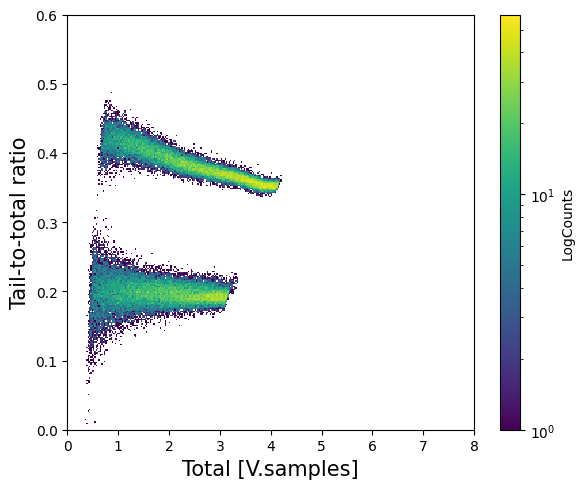

In [ ]:
## energy cuts
peak_position_max=60
Vsamples_range=(0.08, 4.0) # 0.08, 4.0
Vpeak_range=(0.05, 999) #(0.05, 999)
late_window = [20, 200] # 30, 100
afterpulse_frac = 0.10 #0.08
## Templates
amplitudeV = (0.05, 0.35) # no neutrons after 0.35...
Nbins = 6
## Synthetic Samples
sigma_noise = 0.002
min_voltage = 0.05
max_voltage = 0.35 ## cannot go too high because PSD gets distorted
Npulses = 35000 # 100000 is ok, 500000 takes 10s

# --------------------------------------------------
# Selection
# --------------------------------------------------

data_sel, labels_sel, cutflow = gsd.tight_selection(data_merged, labels_merged, 
                                                  Vsamples_range, 
                                                  Vpeak_range,
                                                  peak_position_max,
                                                  late_window, 
                                                  afterpulse_frac)


df = gsd.cutflow_table(cutflow)

ref_plot(data_sel[labels_sel==1], data_sel[labels_sel==0], Npulses = 1000, txt = 'Selection')

# --------------------------------------------------
# Templates
# --------------------------------------------------
neutrons_sel = data_sel[labels_sel == 1]
gammas_sel   = data_sel[labels_sel == 0]
bin_edges = np.linspace(amplitudeV[0], amplitudeV[1], Nbins+1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
print('bin_edges', bin_edges)
print('bin_centers', bin_centers)
print('\nneutrons')
bin_centers, templates_n, templates_n_norm = gsd.make_templates(neutrons_sel, bin_edges, align = False)
print('\ngammas')
bin_centers, templates_g, templates_g_norm = gsd.make_templates(gammas_sel, bin_edges, align = False) ## something here -> align not really working; makes PSD look worse...

ref_plot(templates_n, templates_g, Npulses = Nbins, txt = 'Templates')

# --------------------------------------------------
# Synthetic Samples
# --------------------------------------------------
print('NEUTRONS')
neutrons_synth, _ = gsd.generate_sample(templates = templates_n_norm, 
                                 bin_centers =  bin_centers, 
                                 Npulses = Npulses, 
                                 sigma = sigma_noise,
                                 A_min=min_voltage, 
                                 A_max=max_voltage,
                                 Normalize=False) # if True PSD doesn't work
print('GAMMAS')
gammas_synth, _ = gsd.generate_sample(templates = templates_g_norm, 
                                 bin_centers =  bin_centers, 
                                 Npulses = Npulses, 
                                 sigma = sigma_noise,
                                 A_min=min_voltage, 
                                 A_max=max_voltage,
                                 Normalize=False) # if True PSD doesn't work
ref_plot(neutrons_synth, gammas_synth, Npulses = 1000, txt = 'Synthetic')

data_synth = np.concatenate((neutrons_synth, gammas_synth), axis=0)
totals,ttr = gsd.get_psd_integrals(data_synth)

plt.figure(figsize=(6, 5))
plt.hist2d(
    totals,
    ttr,
    bins=[300, 300],
    range=[[0, 8], [0, 0.6]],
    norm=LogNorm(),
    cmap="viridis"
)
plt.colorbar(label="LogCounts")
plt.xlabel('Total [V.samples]', fontsize = 15)
plt.ylabel("Tail-to-total ratio", fontsize = 15)
plt.tight_layout()
plt.show()

# Step                       N    eff_abs    eff_rel    N_neutron    eff_neutron    N_gamma    eff_gamma
# --------------------  ------  ---------  ---------  -----------  -------------  ---------  -----------
# Input                 112695     1.0000     1.0000        54342         1.0000      58353       1.0000
# Energy selection      109216     0.9691     0.9691        54203         0.9974      55013       0.9428
# Amplitude cut          37942     0.3367     0.3474        12217         0.2254      25725       0.4676
# Afterpulse rejection   32444     0.2879     0.8551         6725         0.5505      25719       0.9998

Step                       N    eff_abs    eff_rel    N_neutron    eff_neutron    N_gamma    eff_gamma
--------------------  ------  ---------  ---------  -----------  -------------  ---------  -----------
Input                 112695     1.0000     1.0000        54342         1.0000      58353       1.0000
Peak position cut     110658     0.9819     0.9819        52555         0.9671      58103       0.9957
Energy selection      107218     0.9514     0.9689        52452         0.9652      54766       0.9385
Amplitude cut          37678     0.3343     0.3514        11982         0.2205      25696       0.4404
Afterpulse rejection   32412     0.2876     0.8602         6718         0.1236      25694       0.4403


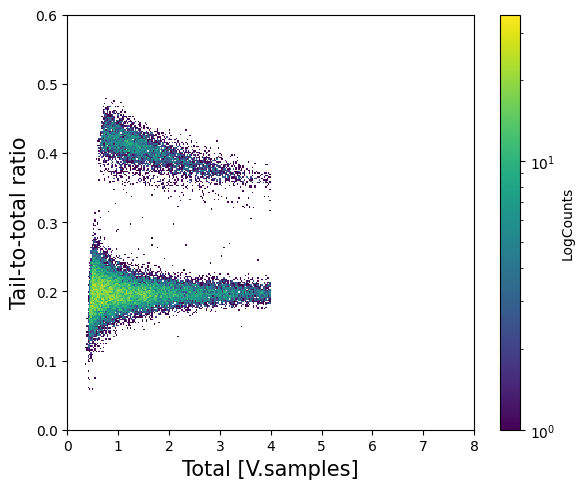

In [7]:
data_clean, labels_clean, cutflow = gsd.tight_selection(data_merged, labels_merged, 
                                                  Vsamples_range, 
                                                  Vpeak_range,
                                                  peak_position_max,
                                                  late_window, 
                                                  afterpulse_frac)
df = gsd.cutflow_table(cutflow)


totals,ttr = gsd.get_psd_integrals(data_clean)
plt.figure(figsize=(6, 5))
# no cuts
plt.hist2d(
    totals,
    ttr,
    bins=[300, 300],
    range=[[0, 8], [0, 0.6]],
    norm=LogNorm(),
    cmap="viridis"
)
plt.colorbar(label="LogCounts")
plt.xlabel('Total [V.samples]', fontsize = 15)
plt.ylabel("Tail-to-total ratio", fontsize = 15)
plt.tight_layout()
plt.show()